In [ ]:
C1

In [1]:
from pyspark.sql import SparkSession

# 1. Iniciamos Spark en este nuevo notebook
spark = SparkSession.builder.appName("Semana12_Supervisados_Completo").getOrCreate()

# 2. Leemos DIRECTAMENTE los datos que guardamos en el K-Means de la semana 10
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# Mostramos el esquema para asegurar que todo cargó bien
df_clusters.printSchema()

root
 |-- marca: integer (nullable = true)
 |-- precio_raw: double (nullable = true)
 |-- rating: double (nullable = true)
 |-- opiniones: integer (nullable = true)
 |-- precio_kg: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)



In [ ]:
C2

In [2]:
# 1. Renombramos 'prediction' a 'label' para que lo entiendan los modelos supervisados
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos en Entrenamiento (70%) y Prueba (30%)
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Datos de entrenamiento para clasificación: {train_data.count()}")
print(f"Datos de prueba para clasificación: {test_data.count()}")

Datos de entrenamiento para clasificación: 679
Datos de prueba para clasificación: 236


In [ ]:
C3

In [3]:
from pyspark.ml.classification import DecisionTreeClassifier

# Configurar el modelo supervisado usando las características escaladas del K-Means
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)

# Entrenar el modelo
dt_model = dt.fit(train_data)

# Hacer predicciones sobre el set de prueba
predictions_dt = dt_model.transform(test_data)

# Mostrar las primeras 10 predicciones vs la etiqueta real
predictions_dt.select("marca", "label", "prediction", "probability").show(10)

+-----+-----+----------+-------------+
|marca|label|prediction|  probability|
+-----+-----+----------+-------------+
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
+-----+-----+----------+-------------+
only showing top 10 rows



In [ ]:
C4

In [4]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluar el Accuracy (Precisión)
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_dt = evaluator_accuracy.evaluate(predictions_dt)

print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy_dt * 100:.2f}%")
print("\n=== ESTRUCTURA LÓGICA DEL ÁRBOL NATIVO DE SPARK ===")
print(dt_model.toDebugString)

Precisión del Árbol de Decisión (Accuracy): 100.00%

=== ESTRUCTURA LÓGICA DEL ÁRBOL NATIVO DE SPARK ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_08e65bc2fbf8, depth=3, numNodes=15, numClasses=3, numFeatures=4
  If (feature 2 <= 1.1857852061682543)
   If (feature 0 <= 3.548416709314404)
    If (feature 3 <= 2.2847094296863824)
     Predict: 0.0
    Else (feature 3 > 2.2847094296863824)
     Predict: 1.0
   Else (feature 0 > 3.548416709314404)
    If (feature 0 <= 4.15166587269519)
     Predict: 1.0
    Else (feature 0 > 4.15166587269519)
     Predict: 2.0
  Else (feature 2 > 1.1857852061682543)
   If (feature 0 <= 2.467671484497751)
    If (feature 3 <= 1.4554022625520897)
     Predict: 0.0
    Else (feature 3 > 1.4554022625520897)
     Predict: 1.0
   Else (feature 0 > 2.467671484497751)
    If (feature 0 <= 4.15166587269519)
     Predict: 1.0
    Else (feature 0 > 4.15166587269519)
     Predict: 2.0



In [ ]:
C5

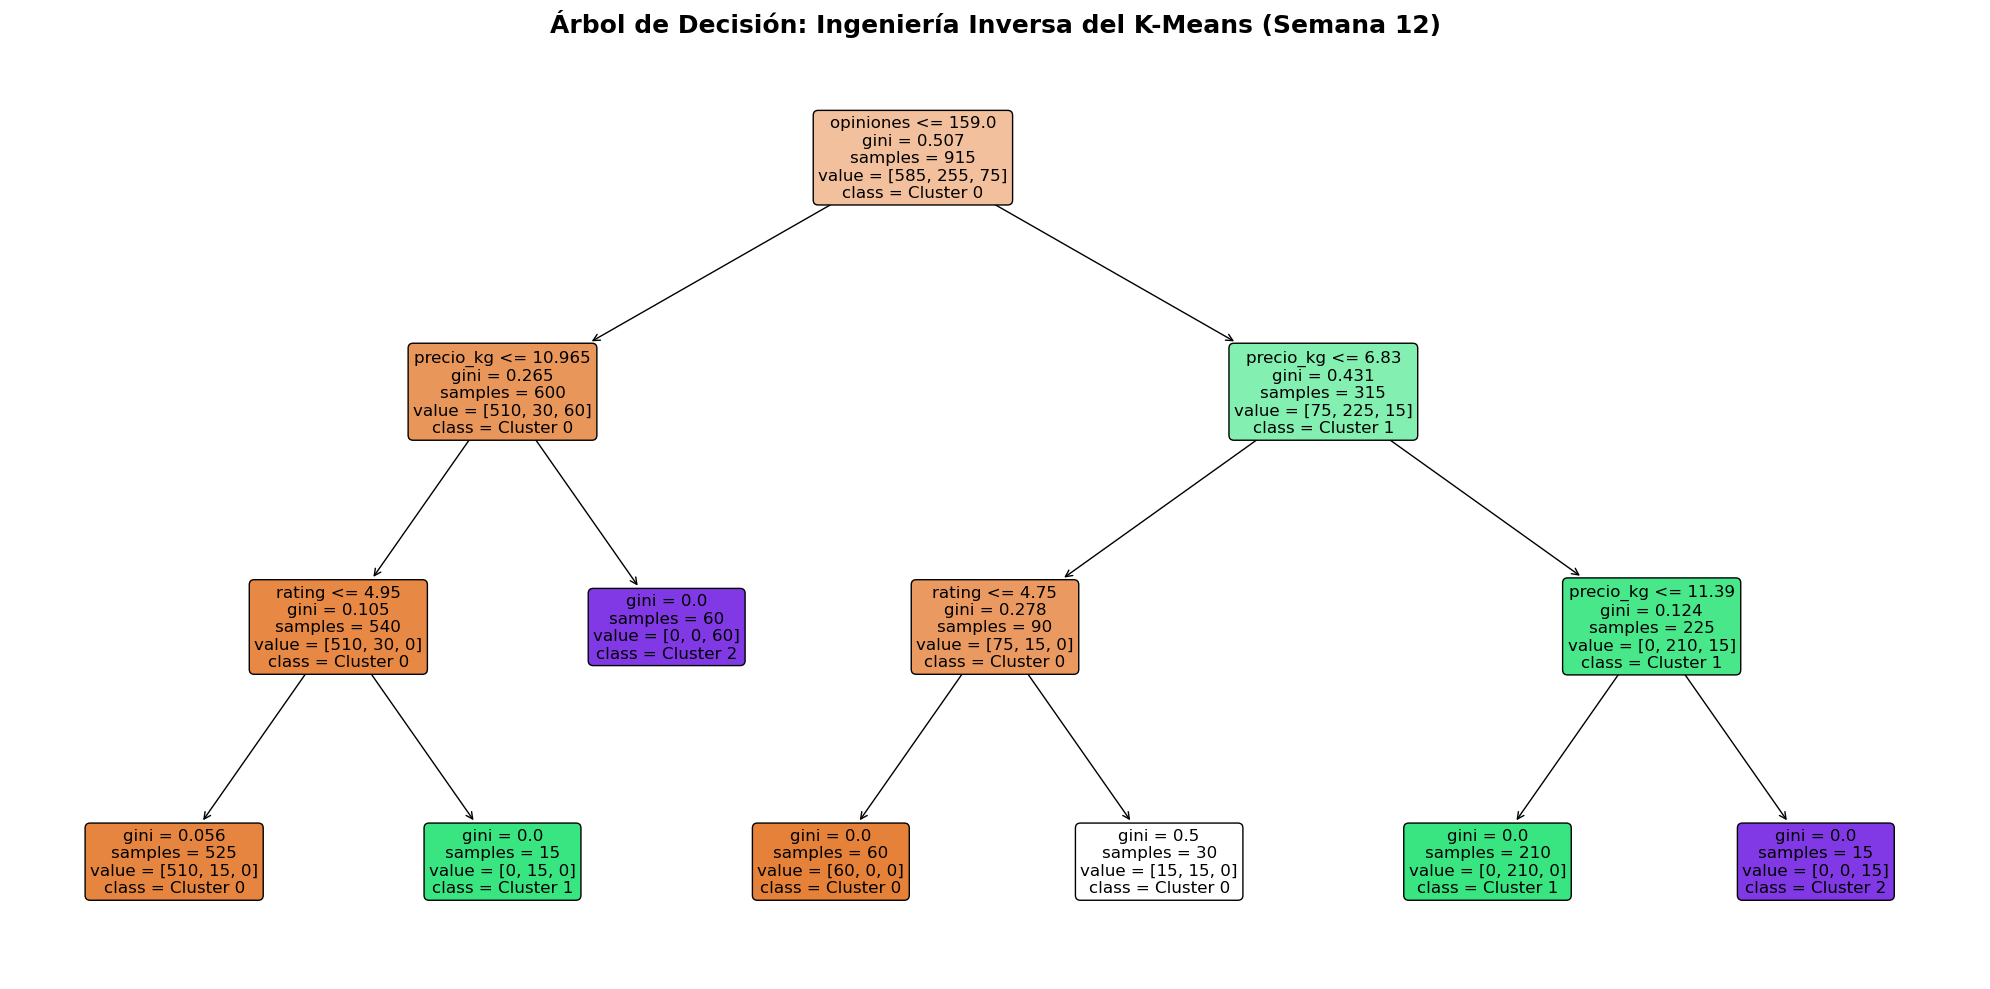

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# 1. Convertimos una muestra a Pandas para poder graficarlo con librerías tradicionales
df_pandas = df_supervisado.select("precio_kg", "rating", "opiniones", "label").toPandas()

# 2. Separamos características (X) y etiqueta (y)
X_muestra = df_pandas[["precio_kg", "rating", "opiniones"]]
y_muestra = df_pandas["label"]

# 3. Entrenamos rápidamente en Scikit-Learn solo para capturar la estructura visual
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Graficamos el árbol con ramas y colores
nombres_features = ["precio_kg", "rating", "opiniones"]
nombres_clases = [f"Cluster {int(c)}" for c in sorted(y_muestra.unique())]

plt.figure(figsize=(20, 10), dpi=100)
plot_tree(sk_dt, feature_names=nombres_features, class_names=nombres_clases, filled=True, rounded=True, fontsize=12)
plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Semana 12)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
C6

In [7]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest

# --- MODELO 1: Random Forest ---
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator_accuracy.evaluate(rf_predictions)

# --- MODELO 2: SVM (Usando OneVsRest porque tenemos 3 clusters y SVM en Spark es binario) ---
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator_accuracy.evaluate(svm_predictions)

# --- MODELO 3: Regresión Logística Multinomial ---
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator_accuracy.evaluate(lr_predictions)

In [ ]:
C7

In [8]:
print("==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) ")
print("==================================================")
print(f"1. Decision Tree Accuracy:   {accuracy_dt * 100:.2f}%")
print(f"2. Random Forest Accuracy:   {accuracy_rf * 100:.2f}%")
print(f"3. SVM (OneVsRest) Accuracy: {accuracy_svm * 100:.2f}%")
print(f"4. Regresión Logística Acc:  {accuracy_lr * 100:.2f}%")
print("==================================================")

 RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) 
1. Decision Tree Accuracy:   100.00%
2. Random Forest Accuracy:   100.00%
3. SVM (OneVsRest) Accuracy: 100.00%
4. Regresión Logística Acc:  100.00%


In [ ]:
C8

In [9]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# 1. Creamos un nuevo VectorAssembler que excluya los precios para evitar Data Leakage
assembler_regresion = VectorAssembler(inputCols=["rating", "opiniones"], outputCol="features_regresion")
df_vector_reg = assembler_regresion.transform(df_clusters)

# 2. Escalamos las nuevas características del modelo de regresión
scaler_reg = StandardScaler(inputCol="features_regresion", outputCol="scaledFeatures_regresion")
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = scaler_model_reg.transform(df_vector_reg)

# 3. Renombramos la variable objetivo a 'label_precio' y eliminamos la columna prediction anterior
df_para_regresion = df_para_regresion.withColumnRenamed("precio_kg", "label_precio").drop("prediction")

# 4. Dividimos en Entrenamiento (70%) y Prueba (30%) para la regresión
train_reg, test_reg = df_para_regresion.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de entrenamiento (Regresión): {train_reg.count()}")
print(f"Registros de prueba (Regresión): {test_reg.count()}")

Registros de entrenamiento (Regresión): 679
Registros de prueba (Regresión): 236


In [ ]:
C9

In [10]:
from pyspark.ml.regression import LinearRegression

# 1. Configurar el modelo
lr_regresion = LinearRegression(featuresCol="scaledFeatures_regresion", labelCol="label_precio", maxIter=10)

# 2. Entrenar con el set de regresión
lr_reg_model = lr_regresion.fit(train_reg)

# 3. Generar las predicciones de precios
predictions_regresion = lr_reg_model.transform(test_reg)

# 4. Mostrar comparativa inicial de resultados
print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("marca", "label_precio", "prediction").show(10)

=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+-----+------------------+-----------------+
|marca|      label_precio|       prediction|
+-----+------------------+-----------------+
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|6.887154858970275|
|    0|12.569999694824219|7.317322158572727|
|    0|12.569999694824219|7.317322158572727|
|    0|12.569999694824219|7.317322158572727|
|    0|12.569999694824219|7.317322158572727|
+-----+------------------+-----------------+
only showing top 10 rows



In [ ]:
C10

In [11]:
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Instanciar los evaluadores de métricas continuas (R2 y RMSE)
evaluator_r2 = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

print("==================================================")
print(" EVALUACIÓN DE LA REGRESIÓN (SEMANA 12) ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2 * 100:.2f}%")
print(f"RMSE (Error promedio en dinero): {rmse:.4f}")
print("==================================================")

# 2. Extraer los datos de la ecuación matemática (Y = mX + b)
print(f"Intersección (Precio base estático): {lr_reg_model.intercept:.4f}")
print(f"Coeficiente de 'rating' (m1): {lr_reg_model.coefficients[0]:.4f}")
print(f"Coeficiente de 'opiniones' (m2): {lr_reg_model.coefficients[1]:.4f}")

 EVALUACIÓN DE LA REGRESIÓN (SEMANA 12) 
R² (Coeficiente de Determinación): 5.68%
RMSE (Error promedio en dinero): 2.8363
Intersección (Precio base estático): -14.6993
Coeficiente de 'rating' (m1): 0.6410
Coeficiente de 'opiniones' (m2): 0.0421


In [ ]:
1. ¿El problema es el algoritmo o los datos?

In [ ]:
l problema son los datos: el algoritmo calcula bien, pero da un R de apenas 5.68% porque las estrellas (rating) y comentarios (opiniones) no influyen en el precio real de un producto. Esto contrasta con la clasificación (que dio 100%), donde los modelos solo memorizaron las reglas artificiales que el K-Means ya había dibujado.

In [ ]:
¿Cómo lo solucionarían en el mundo real sin hacer trampa? qué datos faltan
en el dataset original que sí determinen el precio de un producto veterinario
(por ejemplo: costo de la materia prima, margen de ganancia de la tienda,
si es importado o nacional, peso neto empaque, etc.). o en sus datos,
como fué el algoritmo?

In [ ]:
Se soluciona agregando variables comerciales que sí fijen el precio. Faltan datos críticos como el peso neto del empaque (saco de 15 kg vs. bolsa de 1 kg), la calidad de los ingredientes (premium vs. económico), si es de una línea médica especializada, y su procedencia (importado o nacional).